In [ ]:
# ==========================================
# TASK 1: Import and Inspect the Dataset
# ==========================================

# Enter your CSV file name here
file_name <- "PRSA_Data_Aotizhongxin_20130301-20170228.csv"

# Import dataset with error handling
air_data <- tryCatch({

  # Check if file exists
  if (!file.exists(file_name)) {
    stop("File not found.")
  }

  # Check file extension
  if (tools::file_ext(file_name) != "csv") {
    stop("Incorrect file format. Please provide a CSV file.")
  }

  # Read CSV
  data <- read.csv(file_name, header = TRUE)

  cat("=========================================\n")
  cat("Dataset Imported Successfully!\n")
  cat("=========================================\n\n")

  data

}, error = function(e) {

  cat("ERROR:", conditionMessage(e), "\n")
  return(NULL)

})

# Continue only if dataset loaded successfully
if (!is.null(air_data)) {

  # 1. Display first six records
  cat("=========================================\n")
  cat("1. First Six Records\n")
  cat("=========================================\n")
  print(head(air_data))

  # 2. Display structure
  cat("\n=========================================\n")
  cat("2. Structure of Dataset\n")
  cat("=========================================\n")
  str(air_data)

  # 3. Display number of rows and columns
  cat("\n=========================================\n")
  cat("3. Dataset Dimensions\n")
  cat("=========================================\n")
  cat("Number of Rows    :", nrow(air_data), "\n")
  cat("Number of Columns :", ncol(air_data), "\n")

  # 4. Check whether dataset contains missing values
  cat("\n=========================================\n")
  cat("4. Missing Value Check\n")
  cat("=========================================\n")

  if (any(is.na(air_data))) {
    cat("Dataset contains missing values.\n")
  } else {
    cat("Dataset does not contain missing values.\n")
  }

  # 5. Display total missing values
  cat("\n=========================================\n")
  cat("5. Total Missing Values\n")
  cat("=========================================\n")

  total_missing <- sum(is.na(air_data))
  cat("Total Missing Values :", total_missing, "\n")

}

Dataset Imported Successfully!

1. First Six Records
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

2. Structure of Dataset
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ..

In [ ]:
# ==========================================
# TASK 2: Understand NA, NULL and NaN
# ==========================================

cat("=========================================\n")
cat("TASK 2: NA, NULL and NaN Demonstration\n")
cat("=========================================\n\n")

# Example of NA
temperature <- c(28, 30, NA, 32)

cat("Example of NA:\n")
print(temperature)

cat("\nChecking NA using is.na():\n")
print(is.na(temperature))

cat("\n-----------------------------------------\n")

# Example of NULL
missing_object <- NULL

cat("Example of NULL:\n")
print(missing_object)

cat("\nChecking NULL using is.null():\n")
print(is.null(missing_object))

cat("\n-----------------------------------------\n")

# Example of NaN
undefined_value <- 0 / 0

cat("Example of NaN:\n")
print(undefined_value)

cat("\nChecking NaN using is.nan():\n")
print(is.nan(undefined_value))

cat("\nChecking NaN using is.na():\n")
print(is.na(undefined_value))

cat("\n-----------------------------------------\n")

# Combined Example
values <- c(10, NA, NaN, 25)

cat("Combined Vector:\n")
print(values)

cat("\nis.na() Result:\n")
print(is.na(values))

cat("\nis.nan() Result:\n")
print(is.nan(values))

cat("\n=========================================\n")
cat("Observation:\n")
cat("1. NA represents a missing value.\n")
cat("2. NULL represents an empty object.\n")
cat("3. NaN represents an undefined numerical result.\n")
cat("4. is.na() detects both NA and NaN.\n")
cat("5. is.nan() detects only NaN.\n")
cat("6. is.null() detects only NULL objects.\n")
cat("=========================================\n")

TASK 2: NA, NULL and NaN Demonstration

Example of NA:
[1] 28 30 NA 32

Checking NA using is.na():
[1] FALSE FALSE  TRUE FALSE

-----------------------------------------
Example of NULL:
NULL

Checking NULL using is.null():
[1] TRUE

-----------------------------------------
Example of NaN:
[1] NaN

Checking NaN using is.nan():
[1] TRUE

Checking NaN using is.na():
[1] TRUE

-----------------------------------------
Combined Vector:
[1]  10  NA NaN  25

is.na() Result:
[1] FALSE  TRUE  TRUE FALSE

is.nan() Result:
[1] FALSE FALSE  TRUE FALSE

Observation:
1. NA represents a missing value.
2. NULL represents an empty object.
3. NaN represents an undefined numerical result.
4. is.na() detects both NA and NaN.
5. is.nan() detects only NaN.
6. is.null() detects only NULL objects.


In [ ]:
# ==========================================
# TASK 3: Create Missing Value Summary Function
# ==========================================

# User-defined function
missing_summary <- function(data) {

  # Selected variables
  selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

  # Empty data frame for storing results
  summary_table <- data.frame(
    Variable = character(),
    Total_Records = integer(),
    Missing_Values = integer(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  # Loop through selected variables
  for (var in selected_variables) {

    # Check if variable exists
    if (!(var %in% names(data))) {
      warning(paste("Variable", var, "does not exist in the dataset."))
      next
    }

    total_records <- nrow(data)
    missing_values <- sum(is.na(data[[var]]))
    missing_percentage <- (missing_values / total_records) * 100

    # Add row to summary table
    summary_table <- rbind(
      summary_table,
      data.frame(
        Variable = var,
        Total_Records = total_records,
        Missing_Values = missing_values,
        Missing_Percentage = round(missing_percentage, 2)
      )
    )

    # Warning if missing percentage > 20%
    if (missing_percentage > 20) {
      warning(paste(var, "contains more than 20% missing values."))
    }
  }

  return(summary_table)
}

# Call the function
cat("=========================================\n")
cat("TASK 3: Missing Value Summary\n")
cat("=========================================\n\n")

summary_result <- missing_summary(air_data)

print(summary_result)

TASK 3: Missing Value Summary

  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


In [ ]:
# ==========================================
# TASK 4: Identify Invalid Numerical Results
# ==========================================

cat("=========================================\n")
cat("TASK 4: Identify Invalid Numerical Results\n")
cat("=========================================\n\n")

# Create pollution_ratio
air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

# Count invalid values before replacement
na_count <- sum(is.na(air_data$pollution_ratio))
nan_count <- sum(is.nan(air_data$pollution_ratio))
positive_inf <- sum(air_data$pollution_ratio == Inf, na.rm = TRUE)
negative_inf <- sum(air_data$pollution_ratio == -Inf, na.rm = TRUE)
infinite_count <- sum(is.infinite(air_data$pollution_ratio))

# Display counts before replacement
cat("Before Replacement:\n")
cat("NA Values               :", na_count, "\n")
cat("NaN Values              :", nan_count, "\n")
cat("Positive Infinity       :", positive_inf, "\n")
cat("Negative Infinity       :", negative_inf, "\n")
cat("Total Infinite Values   :", infinite_count, "\n\n")

# Replace NaN and Infinite values with NA
air_data$pollution_ratio[is.nan(air_data$pollution_ratio)] <- NA
air_data$pollution_ratio[is.infinite(air_data$pollution_ratio)] <- NA

# Count invalid values after replacement
na_after <- sum(is.na(air_data$pollution_ratio))
nan_after <- sum(is.nan(air_data$pollution_ratio))
infinite_after <- sum(is.infinite(air_data$pollution_ratio))

# Display counts after replacement
cat("After Replacement:\n")
cat("NA Values               :", na_after, "\n")
cat("NaN Values              :", nan_after, "\n")
cat("Infinite Values         :", infinite_after, "\n")

cat("\n=========================================\n")
cat("Task 4 Completed Successfully!\n")
cat("All NaN and Infinite values have been replaced with NA.\n")
cat("=========================================\n")

TASK 4: Identify Invalid Numerical Results

Before Replacement:
NA Values               : 934 
NaN Values              : 0 
Positive Infinity       : 0 
Negative Infinity       : 0 
Total Infinite Values   : 0 

After Replacement:
NA Values               : 934 
NaN Values              : 0 
Infinite Values         : 0 

Task 4 Completed Successfully!
All NaN and Infinite values have been replaced with NA.


In [ ]:
# ==========================================
# TASK 5: Handle Missing Numerical Values Using a Loop
# ==========================================

cat("=========================================\n")
cat("TASK 5: Handle Missing Numerical Values\n")
cat("=========================================\n\n")

# Selected numerical variables
numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

# Loop through each variable
for (var in numeric_variables) {

  cat("-----------------------------------------\n")
  cat("Variable:", var, "\n")

  # Check whether the column exists
  if (!(var %in% names(air_data))) {
    cat("Column does not exist.\n\n")
    next
  }

  # Count missing values before replacement
  missing_before <- sum(is.na(air_data[[var]]))

  # Calculate median
  median_value <- median(air_data[[var]], na.rm = TRUE)

  # Replace missing values with median
  air_data[[var]][is.na(air_data[[var]])] <- median_value

  # Count missing values after replacement
  missing_after <- sum(is.na(air_data[[var]]))

  # Display results
  cat("Missing Values Before :", missing_before, "\n")
  cat("Median Used           :", median_value, "\n")
  cat("Missing Values After  :", missing_after, "\n\n")
}

cat("=========================================\n")
cat("Task 5 Completed Successfully!\n")
cat("=========================================\n")

TASK 5: Handle Missing Numerical Values

-----------------------------------------
Variable: PM2.5 
Missing Values Before : 925 
Median Used           : 58 
Missing Values After  : 0 

-----------------------------------------
Variable: PM10 
Missing Values Before : 718 
Median Used           : 87 
Missing Values After  : 0 

-----------------------------------------
Variable: SO2 
Missing Values Before : 935 
Median Used           : 9 
Missing Values After  : 0 

-----------------------------------------
Variable: NO2 
Missing Values Before : 1023 
Median Used           : 53 
Missing Values After  : 0 

-----------------------------------------
Variable: TEMP 
Missing Values Before : 20 
Median Used           : 14.5 
Missing Values After  : 0 

-----------------------------------------
Variable: WSPM 
Missing Values Before : 14 
Median Used           : 1.4 
Missing Values After  : 0 

Task 5 Completed Successfully!


In [ ]:
# ==========================================
# TASK 6: Handle Missing Categorical Values
# ==========================================

cat("=========================================\n")
cat("TASK 6: Handle Missing Categorical Values\n")
cat("=========================================\n\n")

# User-defined function to calculate mode
calculate_mode <- function(x) {

  # Remove missing values
  x <- x[!is.na(x)]

  # Find unique values
  unique_values <- unique(x)

  # Count frequency of each value
  frequency <- tabulate(match(x, unique_values))

  # Return most frequent value
  mode_value <- unique_values[which.max(frequency)]

  return(mode_value)
}

# Check if wd column exists
if ("wd" %in% names(air_data)) {

  # Missing values before replacement
  missing_before <- sum(is.na(air_data$wd))

  # Calculate mode
  mode_wd <- calculate_mode(air_data$wd)

  # Replace missing values with mode
  air_data$wd[is.na(air_data$wd)] <- mode_wd

  # Missing values after replacement
  missing_after <- sum(is.na(air_data$wd))

  # Display results
  cat("Variable               : wd\n")
  cat("Mode of wd             :", mode_wd, "\n")
  cat("Missing Values Before  :", missing_before, "\n")
  cat("Missing Values After   :", missing_after, "\n")

} else {

  cat("Error: Column 'wd' does not exist in the dataset.\n")

}

cat("\n=========================================\n")
cat("Task 6 Completed Successfully!\n")
cat("=========================================\n")

TASK 6: Handle Missing Categorical Values

Variable               : wd
Mode of wd             : NE 
Missing Values Before  : 81 
Missing Values After   : 0 

Task 6 Completed Successfully!


In [ ]:
# ==========================================
# TASK 7: Implement Error Handling
# ==========================================

cat("=========================================\n")
cat("TASK 7: Error Handling Using tryCatch()\n")
cat("=========================================\n\n")

# Function to clean a numerical variable
clean_variable <- function(data, variable_name) {

  tryCatch({

    # Check if variable exists
    if (!(variable_name %in% names(data))) {
      stop(paste("Variable", variable_name, "does not exist in the dataset."))
    }

    # Extract the column
    variable <- data[[variable_name]]

    # Check if variable is numeric
    if (!is.numeric(variable)) {
      stop(paste(variable_name, "is not a numerical variable."))
    }

    # Check if all values are missing
    if (all(is.na(variable))) {
      stop(paste(variable_name, "contains only missing values."))
    }

    # Calculate median
    median_value <- median(variable, na.rm = TRUE)

    # Check if median is valid
    if (is.na(median_value)) {
      stop(paste("Median cannot be calculated for", variable_name))
    }

    # Missing values before replacement
    missing_before <- sum(is.na(variable))

    # Replace missing values
    variable[is.na(variable)] <- median_value

    # Missing values after replacement
    missing_after <- sum(is.na(variable))

    # Display results
    cat("-----------------------------------------\n")
    cat("Variable                :", variable_name, "\n")
    cat("Median Used             :", median_value, "\n")
    cat("Missing Before          :", missing_before, "\n")
    cat("Missing After           :", missing_after, "\n\n")

    # Return cleaned variable
    return(variable)

  }, error = function(e) {

    cat("ERROR:", conditionMessage(e), "\n\n")
    return(NULL)

  })
}

# ==========================================
# Apply Function to Selected Variables
# ==========================================

numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

for (var in numeric_variables) {

  cleaned_column <- clean_variable(air_data, var)

  if (!is.null(cleaned_column)) {
    air_data[[var]] <- cleaned_column
  }

}

cat("=========================================\n")
cat("Task 7 Completed Successfully!\n")
cat("=========================================\n")

TASK 7: Error Handling Using tryCatch()

-----------------------------------------
Variable                : PM2.5 
Median Used             : 58 
Missing Before          : 0 
Missing After           : 0 

-----------------------------------------
Variable                : PM10 
Median Used             : 87 
Missing Before          : 0 
Missing After           : 0 

-----------------------------------------
Variable                : SO2 
Median Used             : 9 
Missing Before          : 0 
Missing After           : 0 

-----------------------------------------
Variable                : NO2 
Median Used             : 53 
Missing Before          : 0 
Missing After           : 0 

-----------------------------------------
Variable                : TEMP 
Median Used             : 14.5 
Missing Before          : 0 
Missing After           : 0 

-----------------------------------------
Variable                : WSPM 
Median Used             : 1.4 
Missing Before          : 0 
Missing Af

In [ ]:
# ==========================================
# TASK 8: Compare Missing Values Before and After Cleaning
# ==========================================

cat("=========================================\n")
cat("TASK 8: Comparison of Missing Values\n")
cat("=========================================\n\n")

# Selected variables
selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

# Missing values BEFORE cleaning
missing_before <- c(
  sum(is.na(read.csv(file_name)$`PM2.5`)),
  sum(is.na(read.csv(file_name)$PM10)),
  sum(is.na(read.csv(file_name)$SO2)),
  sum(is.na(read.csv(file_name)$NO2)),
  sum(is.na(read.csv(file_name)$TEMP)),
  sum(is.na(read.csv(file_name)$WSPM)),
  sum(is.na(read.csv(file_name)$wd))
)

# Missing values AFTER cleaning
missing_after <- c(
  sum(is.na(air_data$`PM2.5`)),
  sum(is.na(air_data$PM10)),
  sum(is.na(air_data$SO2)),
  sum(is.na(air_data$NO2)),
  sum(is.na(air_data$TEMP)),
  sum(is.na(air_data$WSPM)),
  sum(is.na(air_data$wd))
)

# Values replaced
values_replaced <- missing_before - missing_after

# Comparison table
comparison_table <- data.frame(
  Variable = selected_variables,
  Missing_Before = missing_before,
  Missing_After = missing_after,
  Values_Replaced = values_replaced
)

# Display comparison table
print(comparison_table)

cat("\n=========================================\n")
cat("Interpretation:\n")
cat("The comparison table shows the number of missing values before and after data cleaning.\n")
cat("If the 'Missing After' column contains 0 for all variables, then all selected missing values\n")
cat("have been handled successfully using median (numerical variables) and mode (wd).\n")
cat("=========================================\n")

TASK 8: Comparison of Missing Values

  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81             0              81

Interpretation:
The comparison table shows the number of missing values before and after data cleaning.
If the 'Missing After' column contains 0 for all variables, then all selected missing values
have been handled successfully using median (numerical variables) and mode (wd).


TASK 9: Missing Value Visualization

Bar chart generated successfully.


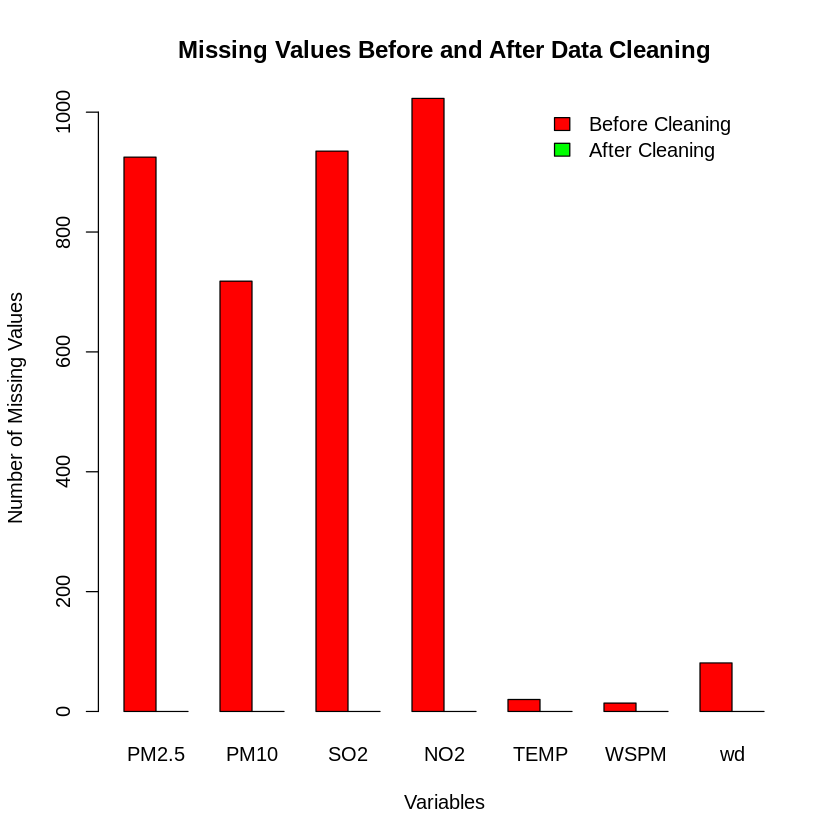

In [ ]:
# ==========================================
# TASK 9: Generate Missing Value Visualization
# ==========================================

cat("=========================================\n")
cat("TASK 9: Missing Value Visualization\n")
cat("=========================================\n\n")

# Read original dataset
original_data <- read.csv(file_name)

# Selected variables
selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

# Missing values before cleaning
missing_before <- sapply(selected_variables, function(x) {
  sum(is.na(original_data[[x]]))
})

# Missing values after cleaning
missing_after <- sapply(selected_variables, function(x) {
  sum(is.na(air_data[[x]]))
})

# Create matrix for bar plot
missing_matrix <- rbind(missing_before, missing_after)

# Generate bar chart
barplot(
  missing_matrix,
  beside = TRUE,
  col = c("red", "green"),
  names.arg = selected_variables,
  main = "Missing Values Before and After Data Cleaning",
  xlab = "Variables",
  ylab = "Number of Missing Values",
  legend.text = c("Before Cleaning", "After Cleaning"),
  args.legend = list(x = "topright", bty = "n")
)

cat("Bar chart generated successfully.\n")

In [ ]:
# ==========================================
# TASK 10: Export the Cleaned Dataset
# ==========================================

cat("=========================================\n")
cat("TASK 10: Export Cleaned Dataset\n")
cat("=========================================\n\n")

# Output file name
output_file <- "cleaned_air_quality_data.csv"

# Export cleaned dataset
write.csv(
  air_data,
  file = output_file,
  row.names = FALSE
)

# Verify export
if (file.exists(output_file)) {

  cat("Dataset exported successfully!\n")
  cat("File Name :", output_file, "\n")
  cat("Location  :", getwd(), "\n")

} else {

  cat("Error: Dataset could not be exported.\n")

}

cat("\n=========================================\n")
cat("Task 10 Completed Successfully!\n")
cat("=========================================\n")

TASK 10: Export Cleaned Dataset

Dataset exported successfully!
File Name : cleaned_air_quality_data.csv 
Location  : /content 

Task 10 Completed Successfully!
